**Profit Analysis**


In [29]:
import pandas as pd
import pyspark as py
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df=pd.read_csv("/content/ecommerce_sales_data (2).csv")

In [31]:
df

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


In [32]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [33]:
df.tail()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28
3499,2024-11-01,Smartwatch,Electronics,East,9,10530,1777.32


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [35]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [36]:
df

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


In [37]:
df.describe()

,Order Date,Quantity,Sales,Profit
count,3500,3500.000000,3500.000000,3500.000000
mean,2023-07-13 00:53:53.828571648,4.931714,3047.966000,527.047203
min,2022-01-01 00:00:00,1.000000,51.000000,6.970000
25%,2022-10-16 18:00:00,3.000000,1049.500000,158.695000
50%,2023-07-21 12:00:00,5.000000,2350.500000,361.070000
75%,2024-04-16 06:00:00,7.000000,4537.000000,729.125000
max,2024-12-31 00:00:00,9.000000,10782.000000,2946.930000
std,NaN,2.575895,2440.213237,504.139732


In [38]:
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

In [39]:
df.isnull().sum()

,0
Order Date,0
Product Name,0
Category,0
Region,0
Quantity,0
Sales,0
Profit,0


In [40]:
df.drop_duplicates()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


In [41]:
df['Sales']=df['Sales'].fillna(df['Sales'].median())

In [42]:
df

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


In [43]:
total_sales = df['Sales']
print('Total_sale:',total_sales)

Total_sale: 0        3640
1        1197
2        5865
3         786
4         509
        ...  
3495     4064
3496     1117
3497      260
3498      222
3499    10530
Name: Sales, Length: 3500, dtype: int64


In [44]:
total_profit = df['Profit']
print("Total_profit:", total_profit)

Total_profit: 0        348.93
1        106.53
2        502.73
3        202.87
4        103.28
         ...   
3495     771.16
3496     119.89
3497      66.02
3498      50.28
3499    1777.32
Name: Profit, Length: 3500, dtype: float64


In [45]:
average_profit = df['Profit'].mean()
print("Average_profit:", average_profit)

Average_profit: 527.0472028571428


In [46]:
category_profit = df.groupby("Category")['Profit'].sum()
print(category_profit)

Category
Accessories    736084.74
Electronics    923185.59
Office         185394.88
Name: Profit, dtype: float64


EDA(EXPLORATORY DATA ANALYSIS)

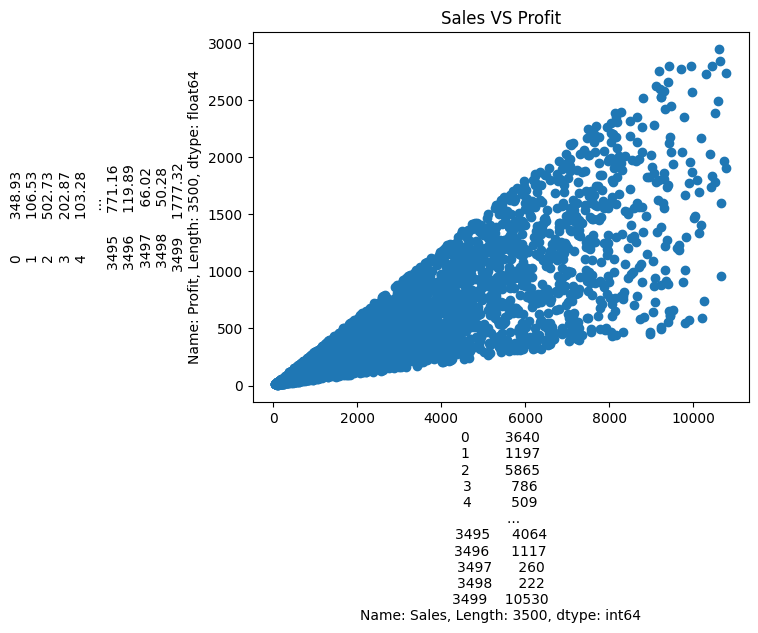

In [47]:
import matplotlib.pyplot as plt
plt.scatter(df['Sales'],df['Profit'])
plt.xlabel(df['Sales'])
plt.ylabel(df['Profit'])
plt.title("Sales VS Profit")
plt.show()

In [48]:
region_profit = df.groupby("Region")["Profit"].sum()
print(region_profit)

Region
East     464888.46
North    426314.75
South    458103.27
West     495358.73
Name: Profit, dtype: float64


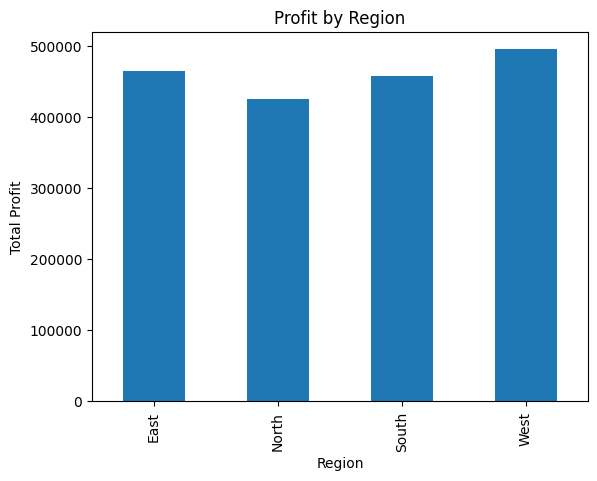

In [49]:
region_profit.plot(kind = "bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

Analyze profit by product

In [50]:
product_profit = df.groupby("Product Name")['Profit'].sum()
print(product_profit.sort_values(ascending=False))

Product Name
Camera        207630.99
Monitor       202028.17
Mouse         185763.69
Laptop        185756.81
Printer       185394.88
Smartphone    183296.97
Smartwatch    178995.81
Keyboard      175814.68
Headphones    172478.20
Tablet        167505.01
Name: Profit, dtype: float64


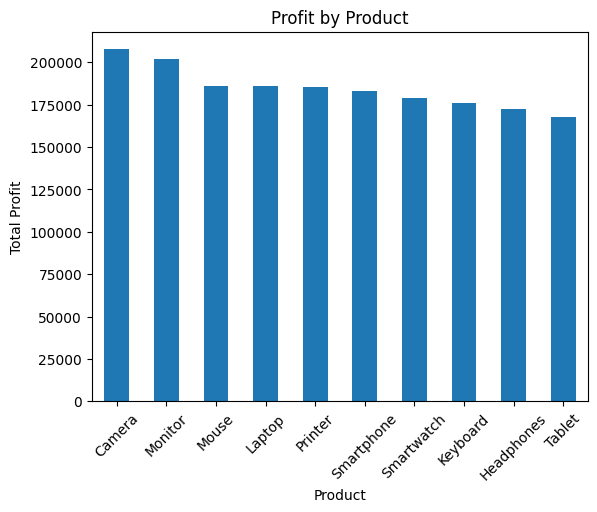

In [51]:
product_profit.sort_values(ascending=False).plot(kind='bar')
plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)

plt.show()

Analyze Sales vs Profit

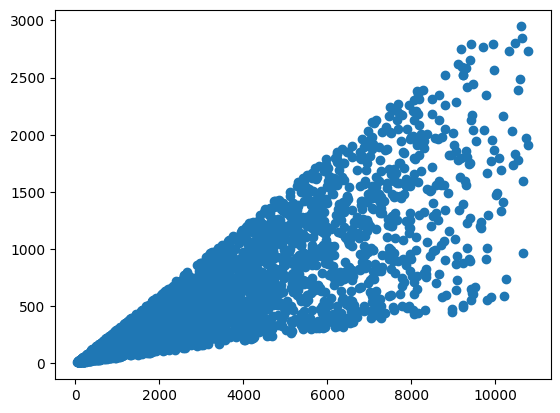

In [52]:
plt.scatter(df['Sales'],df['Profit'])

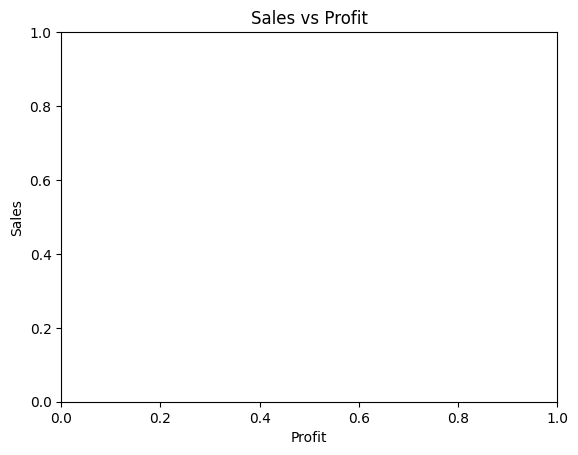

In [53]:
plt.xlabel('Profit')
plt.ylabel('Sales')
plt.title('Sales vs Profit')
plt.show()

Correlation

In [54]:
df[['Quantity','Sales','Profit']].corr()

,Quantity,Sales,Profit
Quantity,1.000000,0.662468,0.560651
Sales,0.662468,1.000000,0.832826
Profit,0.560651,0.832826,1.000000


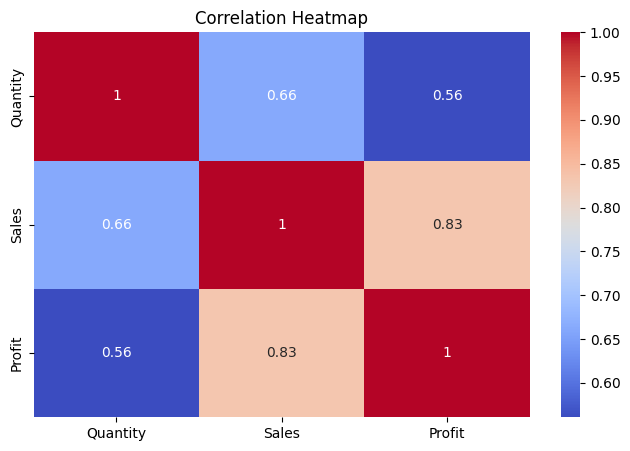

In [55]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Quantity","Sales","Profit"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

Regression Model

In [56]:
x=df[["Quantity","Sales"]]
y=df["Profit"]

In [57]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    train_size=42
)

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
model = LinearRegression()

In [60]:
model.fit(x_train,y_train)

LinearRegression()

Prediction

In [61]:
y_pred=model.predict(x_test)

In [62]:
print(y_pred[:10])

[ 408.78176561 1218.46045406  319.31713945  517.69554762  185.26758846
  398.82166649 1222.99709655 1802.99872532 1612.81998445  160.39497597]


In [63]:
comparison = pd.DataFrame({
    "Actual profit": y_test.values,
    "Predicted Profit":y_pred
})
comparison.head(10)


,Actual profit,Predicted Profit
0,595.05,408.781766
1,1323.10,1218.460454
2,187.72,319.317139
3,782.28,517.695548
4,215.51,185.267588
5,453.04,398.821666
6,1704.80,1222.997097
7,2316.03,1802.998725
8,1708.84,1612.819984
9,73.28,160.394976


In [64]:
from sklearn.metrics import r2_score
r2 = r2_score(y_pred,y_test)
print("R*2 Score:",r2)

R*2 Score: 0.615235528338292


In [65]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
print("MAE:", mae)

MAE: 236.3867958984964


In [66]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test,y_pred)
print("RMSE:", rmse)

RMSE: 344.24586499072103


In [67]:
print("Intercept:", model.intercept_)
print("Coefficient:",model.coef_)

Intercept: -185.67975770960243
Coefficient: [24.71999719  0.20788589]


In [68]:
Coefficients = pd.DataFrame({
   "Features":x.columns,
   "Coefficient":model.coef_
})
print(Coefficients)

   Features  Coefficient
0  Quantity    24.719997
1     Sales     0.207886


Text(0.5, 1.0, 'Actual Vs Predict')

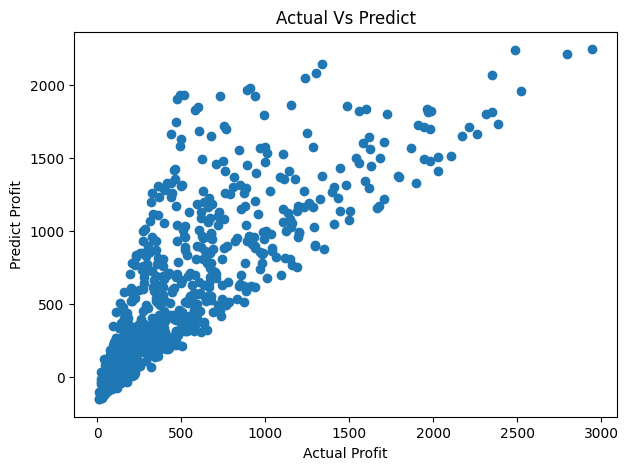

In [69]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predict Profit")
plt.title("Actual Vs Predict")

In [70]:
residuals=y_test-y_pred

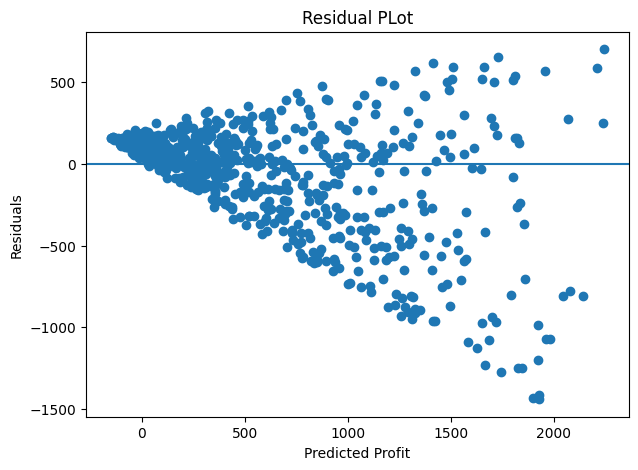

In [71]:
plt.figure(figsize=(7,5))
plt.scatter(y_pred,residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Profit")
plt.ylabel("Residuals")
plt.title("Residual PLot")
plt.show()

In [72]:
new_order=pd.DataFrame({
    "Quantity":[5],
    "Sales":[5000]
})

In [73]:
predicted_profit = model.predict(new_order)
print("Predicted Profit:",predicted_profit[0])

Predicted Profit: 977.3496705201287



Business Insight

---




Overall Performance

---



The e-commerce business generated total sales of 10.67 million and total profit of approximately 1.84 million across 3,500 transactions.

Category Performance

---



Electronics is the most profitable category, generating approximately 923K in total profit. Accessories is the second highest contributor, while Office has considerably lower profit.

Regional Performance

---



The West region generated the highest total profit at approximately 495K, while North generated the lowest at approximately 426K.

Product Performance

---



Camera is the highest-profit product, followed by Monitor. These products are important contributors to overall profitability.

Sales-Profit Relationship

---



Sales and Profit show a [positive/negative] relationship based on the correlation analysis.

Regression Analysis

---



A Linear Regression model was developed using Quantity and Sales to predict Profit. The model achieved an R² score of [actual value], with MAE of [actual value] and RMSE of [actual value].







Recommendations

---



Focus on high-profit categories and products.

Investigate lower-performing categories.

Analyze why the West region performs better.

Use the regression model to support profit forecasting.




**CONCLUSION**

---
This project analyzed an e-commerce sales dataset containing 3,500 transactions to understand sales and profitability across different products, categories, and regions. The analysis showed that Electronics was the highest-profit category, while the West region generated the highest regional profit. Camera and Monitor were among the top-performing products in terms of profit.

A Linear Regression model was developed using Quantity and Sales to predict Profit. The model was evaluated using R², MAE, and RMSE to measure its predictive performance. The analysis also examined the relationship between Sales and Profit to understand the factors associated with profitability.

Finally, an interactive Power BI dashboard was developed to visualize key performance indicators, category and regional profitability, product performance, sales trends, and the relationship between sales and profit. These insights can help businesses identify profitable products and regions, monitor performance, and make better data-driven decisions.
